# 05. Подбор гиперпараметров BERTopic

**Цель:** снизить Noise Ratio (baseline: 0.445) и улучшить DBCV (baseline: 0.389)  
при сохранении высокого C_V Coherence (baseline: 0.808).

**Стратегия:**
- Оптимизатор: **Optuna TPE** (Tree-structured Parzen Estimator) - умнее и быстрее GridSearch,  
  учитывает зависимости между параметрами через multivariate=True  
  -> https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html
- **Быстрая итерация:** гоняем только UMAP -> HDBSCAN -> DBCV на подвыборке 50k.  
  Эмбеддинги уже посчитаны - c-TF-IDF пропускаем до финала.  
  -> https://maartengr.github.io/BERTopic/getting_started/parameter%20tuning/parametertuning.html
- **Целевая функция:** `DBCV - 0.5 * noise_ratio`  
  Штрафуем за высокий шум, но не жертвуем качеством кластеров ради нуля шума.
- **Финал:** топ-3 конфига -> полный BERTopic с c-TF-IDF -> финальное сравнение метрик.

**Baseline (04_bertopic_baseline):**
```
n_topics:        212
noise_ratio:     0.4447
coherence_cv:    0.8083
topic_diversity: 0.7736
dbcv:            0.3889
```

**Пространство поиска:**

| Параметр | Диапазон | Обоснование |
|---|---|---|
| `min_cluster_size` | 50–200 | главный рычаг Noise Ratio; baseline=150 |
| `min_samples` | 5–50 | независимо снижает шум; по умолч. = min_cluster_size |
| `n_neighbors` (UMAP) | 15–100 | локальная vs глобальная структура; baseline=15 |
| `n_components` (UMAP) | 5–15 | размерность пространства кластеризации; baseline=5 |

Источники по выбору диапазонов:
- UMAP: https://umap-learn.readthedocs.io/en/latest/parameters.html
- HDBSCAN: https://hdbscan.readthedocs.io/en/latest/parameter_selection.html
- Практика на больших корпусах: https://maartengr.github.io/BERTopic/faq.html

In [1]:
import warnings

warnings.filterwarnings("ignore")  # UMAP много предупреждений про n_jobs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

import optuna
from optuna.samplers import TPESampler
# Optuna docs: https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html

from umap import UMAP
# UMAP docs: https://umap-learn.readthedocs.io/en/latest/api.html

from hdbscan import HDBSCAN
import hdbscan.validity as dbcv_module
# HDBSCAN docs: https://hdbscan.readthedocs.io/en/latest/api.html
# DBCV validity index: https://hdbscan.readthedocs.io/en/latest/api.html#hdbscan.validity.validity_index

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

print(f"optuna: {optuna.__version__}")

optuna: 4.8.0


In [24]:
# Воспроизводимость
RANDOM_STATE = 42

# Размер подвыборки для быстрой оптимизации
# На 50k одна итерация UMAP+HDBSCAN занимает ~2-4 мин вместо ~15 мин на 300k
OPTUNA_SAMPLE_SIZE = 50_000

# Количество trials в Optuna
# 10 random + 20 TPE = 30 итераций, ~1.5-2 часа
N_TRIALS = 30
N_STARTUP_TRIALS = 10  # сколько случайных trials перед TPE

# Коэффициент штрафа за Noise Ratio в целевой функции
NOISE_PENALTY = 0.5

# Пути
DATA_PATH = Path("data/posts_preprocessed.parquet")
EMBEDDINGS_PATH = Path("data/embeddings_USER-bge-m3_300k.npy")
RESULTS_DIR = Path("results/hyperparams")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

STUDY_DB_PATH = RESULTS_DIR / "optuna_study.db"
OPTUNA_SAMPLE_IDX_PATH = RESULTS_DIR / "optuna_sample_idx.npy"

ID_COLUMN = None

## 2. Загрузка данных и подвыборка для оптимизации

Эмбеддинги уже посчитаны в `03_embeddings.ipynb` - загружаем готовые.  
Для оптимизации берём стратифицированную подвыборку 50k из 300k,  
чтобы сохранить пропорции каналов.

In [3]:
df = pd.read_parquet(DATA_PATH)
embeddings_full = np.load(EMBEDDINGS_PATH)

assert len(df) == len(embeddings_full), "Размеры не совпадают!"
print(f"Постов: {len(df):,} | Эмбеддингов: {len(embeddings_full):,}")
print(f"Размерность эмбеддингов: {embeddings_full.shape[1]}")

Постов: 300,000 | Эмбеддингов: 300,000
Размерность эмбеддингов: 1024


In [ ]:
sample_idx = (
    df.groupby("channel_name", group_keys=False)
    .apply(
        lambda g: g.sample(
            n=min(len(g), int(np.ceil(OPTUNA_SAMPLE_SIZE * len(g) / len(df)))),
            random_state=RANDOM_STATE,
        )
    )
    .index
)

if len(sample_idx) > OPTUNA_SAMPLE_SIZE:
    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = rng.choice(sample_idx, size=OPTUNA_SAMPLE_SIZE, replace=False)

df_sample = df.loc[sample_idx].reset_index(drop=True)
embeddings_sample = embeddings_full[sample_idx]

docs_sample = df_sample["text_lemm"].tolist()

print(f"Подвыборка: {len(df_sample):,} документов")
print(f"Эмбеддинги подвыборки: {embeddings_sample.shape}")
print(f"Каналов в подвыборке: {df_sample['channel_name'].nunique()}")

np.save(OPTUNA_SAMPLE_IDX_PATH, np.asarray(sample_idx))
print(f"Sample index saved: {OPTUNA_SAMPLE_IDX_PATH}")

Подвыборка: 50,000 документов
Эмбеддинги подвыборки: (50000, 1024)
Каналов в подвыборке: 65


## 3. Целевая функция для Optuna

**Что оптимизируем:** `score = DBCV - NOISE_PENALTY * noise_ratio`

- DBCV - основная метрика качества плотностной кластеризации. Правильная замена  
  Silhouette Score для HDBSCAN.  
  -> https://hdbscan.readthedocs.io/en/latest/api.html#hdbscan.validity.validity_index
- Noise Ratio - штраф. 44.5% шума в baseline слишком много для продакшна.
- `NOISE_PENALTY=0.5`: trade-off - снижение шума на 10% ценнее прироста DBCV на 5%.

**Важно:** каждый trial - только UMAP + HDBSCAN, без BERTopic.  
c-TF-IDF запускаем только в разделе 5 для топ-3 конфигов.

In [5]:
def compute_dbcv(
    reduced: np.ndarray, labels: np.ndarray, max_per_cluster: int = 2000
) -> float:
    """
    DBCV с сабсэмплингом внутри кластеров для экономии памяти.
    На датасетах >50k прямой DBCV требует десятки ГБ RAM - сабсэмплинг
    даёт репрезентативную оценку без OOM.

    Источник: https://hdbscan.readthedocs.io/en/latest/api.html#hdbscan.validity.validity_index
    """
    mask = labels != -1
    if mask.sum() < 10 or len(np.unique(labels[mask])) < 2:
        return float("nan")

    rng = np.random.default_rng(42)
    keep_idx = []
    for cluster_id in np.unique(labels[mask]):
        cluster_idx = np.where(labels == cluster_id)[0]
        if len(cluster_idx) > max_per_cluster:
            cluster_idx = rng.choice(cluster_idx, size=max_per_cluster, replace=False)
        keep_idx.extend(cluster_idx)

    keep_idx = np.array(keep_idx)
    try:
        score = dbcv_module.validity_index(
            reduced[keep_idx].astype(np.float64), labels[keep_idx]
        )
        return float(score)
    except Exception as e:
        print(f"  DBCV ошибка: {e}")
        return float("nan")


def objective(trial: optuna.Trial) -> float:
    """
    Целевая функция Optuna.
    Maximizes: DBCV - NOISE_PENALTY * noise_ratio

    Пространство поиска основано на:
    - UMAP параметры: https://umap-learn.readthedocs.io/en/latest/parameters.html
    - HDBSCAN параметры: https://hdbscan.readthedocs.io/en/latest/parameter_selection.html
    - Рекомендации для больших корпусов: https://maartengr.github.io/BERTopic/faq.html
    """
    # --- UMAP параметры ---
    # n_neighbors: меньше = локальная структура (мелкие кластеры),
    # больше = глобальная (крупные слитые темы)
    # Для 300k корпуса baseline=15 слишком мало -> диапазон 15-100
    n_neighbors = trial.suggest_int("n_neighbors", 15, 100)

    # n_components: размерность для кластеризации.
    # 5 (baseline) -> потеря информации; 15 -> медленнее DBCV
    n_components = trial.suggest_int("n_components", 5, 15)

    # --- HDBSCAN параметры ---
    # min_cluster_size: главный рычаг Noise Ratio.
    # baseline=150 -> много шума. Пробуем 50-200.
    # https://hdbscan.readthedocs.io/en/latest/parameter_selection.html#selecting-min-cluster-size
    min_cluster_size = trial.suggest_int("min_cluster_size", 50, 200)

    # min_samples: порог для объявления точки core point.
    # По умолчанию = min_cluster_size, но можно задать меньше.
    # Меньше min_samples -> меньше шума, но рыхлее кластеры.
    # https://hdbscan.readthedocs.io/en/latest/parameter_selection.html#selecting-min-samples
    min_samples = trial.suggest_int("min_samples", 5, 150)

    # --- UMAP ---
    umap_model = UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=0.0,  # 0.0 для плотной кластеризации (рекомендация BERTopic)
        metric="cosine",  # для высокоразмерных эмбеддингов
        random_state=RANDOM_STATE,
        low_memory=False,
    )
    reduced = umap_model.fit_transform(embeddings_sample)

    # --- HDBSCAN ---
    hdbscan_model = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric="euclidean",  # после UMAP - euclidean
        cluster_selection_method="eom",
        prediction_data=True,
    )
    labels = hdbscan_model.fit_predict(reduced)

    # --- Метрики ---
    noise_ratio = float((labels == -1).mean())
    n_clusters = len(np.unique(labels[labels != -1]))
    dbcv = compute_dbcv(reduced, labels)

    # Логируем промежуточные значения
    # -> https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.set_user_attr
    trial.set_user_attr("noise_ratio", noise_ratio)
    trial.set_user_attr("n_clusters", n_clusters)
    trial.set_user_attr("dbcv", dbcv if not np.isnan(dbcv) else -999)

    if np.isnan(dbcv):
        # Если DBCV не посчитался - штрафуем, но не роняем trial
        return -999.0

    score = dbcv - NOISE_PENALTY * noise_ratio
    return score


print("Целевая функция определена")

Целевая функция определена


## 4. Запуск Optuna

TPE (Tree-structured Parzen Estimator) - байесовская оптимизация.

Принцип: строит два GMM - `l(x)` на хороших конфигах и `g(x)` на плохих,  
выбирает параметры где `l(x)/g(x)` максимально.  
Намного умнее grid search: не тратит время на заведомо плохие конфиги.

`multivariate=True` - учитывает зависимости между параметрами (например,  
что при большом `n_components` нужен другой `min_cluster_size`).  
-> https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html

In [ ]:
# Отключаем стандартные логи Optuna - они слишком шумные
# -> https://optuna.readthedocs.io/en/stable/reference/logging.html
optuna.logging.set_verbosity(optuna.logging.WARNING)

sampler = TPESampler(
    n_startup_trials=N_STARTUP_TRIALS,
    multivariate=True,
    warn_independent_sampling=False,
    seed=RANDOM_STATE,
)

storage_url = f"sqlite:///{STUDY_DB_PATH.resolve().as_posix()}"

study = optuna.create_study(
    direction="maximize",  # максимизируем DBCV - penalty * noise
    sampler=sampler,
    study_name="bertopic_hyperparams",
    storage=storage_url,
    load_if_exists=True,
)

print(f"Study создан: {study.study_name}")
print(f"Направление: {study.direction}")
print(f"Storage: {STUDY_DB_PATH}")
print(
    f"Trials: {N_TRIALS} ({N_STARTUP_TRIALS} random + {N_TRIALS - N_STARTUP_TRIALS} TPE)"
)
print(f"Подвыборка: {OPTUNA_SAMPLE_SIZE:,} документов")
print(f"Целевая функция: DBCV - {NOISE_PENALTY} * noise_ratio")
print("\nЗапускаем...")

Study создан: bertopic_hyperparams
Направление: 2
Trials: 30 (10 random + 20 TPE)
Подвыборка: 50,000 документов
Целевая функция: DBCV - 0.5 * noise_ratio

Запускаем...


In [7]:
from tqdm.notebook import tqdm

pbar = tqdm(total=N_TRIALS, desc="Optuna trials")


def progress_callback(study: optuna.Study, trial: optuna.trial.FrozenTrial):
    attrs = trial.user_attrs
    pbar.set_postfix(
        {
            "score": f"{trial.value:.4f}" if trial.value else "?",
            "dbcv": f"{attrs.get('dbcv', '?'):.4f}"
            if isinstance(attrs.get("dbcv"), float)
            else "?",
            "noise": f"{attrs.get('noise_ratio', '?'):.3f}"
            if isinstance(attrs.get("noise_ratio"), float)
            else "?",
            "n_clusters": attrs.get("n_clusters", "?"),
            "best_score": f"{study.best_value:.4f}" if study.trials else "?",
        }
    )
    pbar.update(1)


study.optimize(
    objective,
    n_trials=N_TRIALS,
    callbacks=[progress_callback],
    show_progress_bar=False,
)

pbar.close()
print("\nОптимизация завершена!")
print(f"Лучший score: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

Optuna trials:   0%|          | 0/30 [00:00<?, ?it/s]


Оптимизация завершена!
Лучший score: 0.4954
Лучшие параметры: {'n_neighbors': 54, 'n_components': 15, 'min_cluster_size': 69, 'min_samples': 119}


## 5. Анализ результатов Optuna

In [8]:
trials_data = []
for t in study.trials:
    if t.value is None:
        continue
    row = {**t.params, **t.user_attrs, "score": t.value, "trial_id": t.number}
    trials_data.append(row)

trials_df = pd.DataFrame(trials_data).sort_values("score", ascending=False)
print(f"Успешных trials: {len(trials_df)}")
print("\nТоп-10 конфигов:")
print(trials_df.head(10).to_string(index=False))

Успешных trials: 30

Топ-10 конфигов:
 n_neighbors  n_components  min_cluster_size  min_samples  noise_ratio  n_clusters     dbcv    score  trial_id
          54            15                69          119      0.00116           2 0.495952 0.495372        27
          58            14               148          134      0.00114           2 0.462189 0.461619        29
          51            15               120          142      0.00136           2 0.443014 0.442334        28
          54            13                80           80      0.00114           2 0.412519 0.411949         6
          55            15                58           76      0.56830          72 0.597003 0.312853        20
          32            15                54           58      0.55194         100 0.581795 0.305825        24
          89            15                62           55      0.56154          75 0.565150 0.284380        10
          31            13                64          100      0.55776    

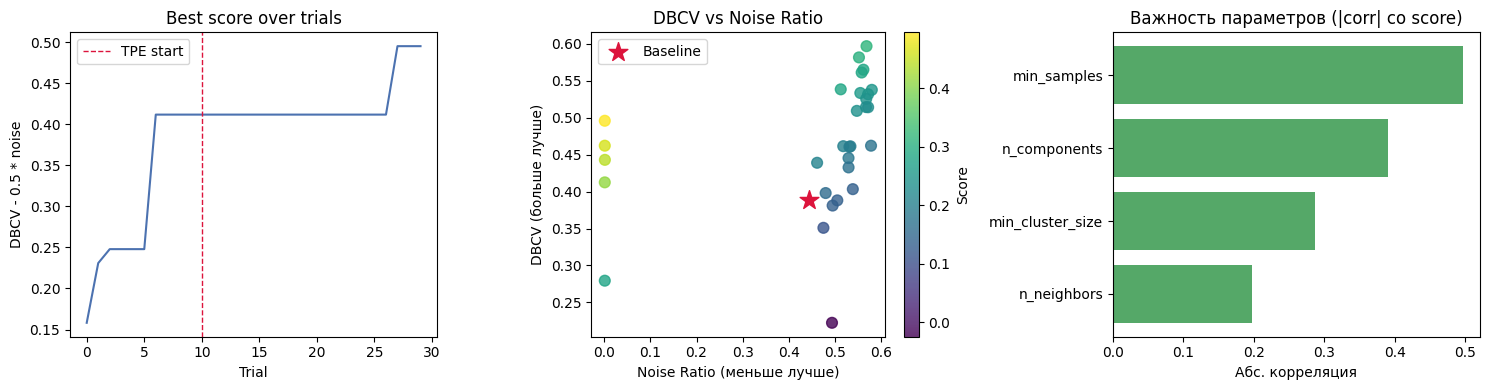

In [9]:
# Визуализация: история оптимизации
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# История лучшего score
best_so_far = trials_df.sort_values("trial_id")["score"].cummax()
axes[0].plot(
    trials_df.sort_values("trial_id")["trial_id"], best_so_far, color="#4C72B0"
)
axes[0].axvline(
    N_STARTUP_TRIALS, color="crimson", linestyle="--", linewidth=1, label="TPE start"
)
axes[0].set_title("Best score over trials")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("DBCV - 0.5 * noise")
axes[0].legend()

# DBCV vs Noise Ratio (trade-off)
scatter = axes[1].scatter(
    trials_df["noise_ratio"],
    trials_df["dbcv"],
    c=trials_df["score"],
    cmap="viridis",
    s=60,
    alpha=0.8,
)
# Baseline
axes[1].scatter(
    [0.4447], [0.3889], color="crimson", marker="*", s=200, zorder=5, label="Baseline"
) 
plt.colorbar(scatter, ax=axes[1], label="Score")
axes[1].set_title("DBCV vs Noise Ratio")
axes[1].set_xlabel("Noise Ratio (меньше лучше)")
axes[1].set_ylabel("DBCV (больше лучше)")
axes[1].legend()

# Важность параметров через корреляцию со score
param_cols = ["n_neighbors", "n_components", "min_cluster_size", "min_samples"]
correlations = (
    trials_df[param_cols + ["score"]]
    .corr()["score"]
    .drop("score")
    .abs()
    .sort_values(ascending=True)
)
axes[2].barh(correlations.index, correlations.values, color="#55A868")
axes[2].set_title("Важность параметров (|corr| со score)")
axes[2].set_xlabel("Абс. корреляция")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_optuna_overview.png", bbox_inches="tight", dpi=130)
plt.show()

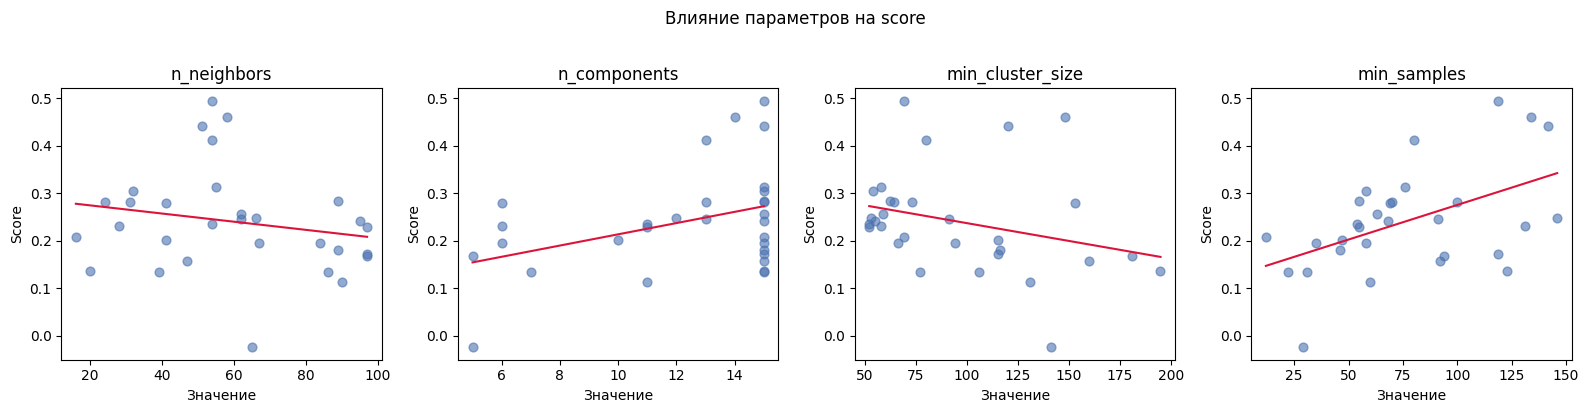

In [10]:
# Влияние каждого параметра на score - scatter plots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
param_cols = ["n_neighbors", "n_components", "min_cluster_size", "min_samples"]

for ax, param in zip(axes, param_cols):
    ax.scatter(trials_df[param], trials_df["score"], alpha=0.6, color="#4C72B0", s=40)
    # Тренд
    z = np.polyfit(trials_df[param], trials_df["score"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(trials_df[param].min(), trials_df[param].max(), 50)
    ax.plot(x_line, p(x_line), color="crimson", linewidth=1.5)
    ax.set_title(param)
    ax.set_xlabel("Значение")
    ax.set_ylabel("Score")

plt.suptitle("Влияние параметров на score", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_param_effects.png", bbox_inches="tight", dpi=130)
plt.show()

In [11]:
# Сохраняем все trials
trials_df.to_csv(RESULTS_DIR / "optuna_trials.csv", index=False)

# Топ-3 конфига для финального запуска
top3 = trials_df.head(3)[
    ["trial_id"] + param_cols + ["dbcv", "noise_ratio", "n_clusters", "score"]
]
print("Топ-3 конфига для финального BERTopic:")
print(top3.to_string(index=False))

top3.to_csv(RESULTS_DIR / "top3_configs.csv", index=False)

Топ-3 конфига для финального BERTopic:
 trial_id  n_neighbors  n_components  min_cluster_size  min_samples     dbcv  noise_ratio  n_clusters    score
       27           54            15                69          119 0.495952      0.00116           2 0.495372
       29           58            14               148          134 0.462189      0.00114           2 0.461619
       28           51            15               120          142 0.443014      0.00136           2 0.442334


## 6. Финальный BERTopic для топ-3 конфигов

Теперь запускаем полный пайплайн: UMAP -> HDBSCAN -> c-TF-IDF -> метрики.  
Считаем C_V Coherence и Topic Diversity - которые нельзя было считать  
на быстрых итерациях без c-TF-IDF.

Запускаем на полных 300k (не на подвыборке).  
-> https://maartengr.github.io/BERTopic/getting_started/best_practices/best_practices.html

In [12]:
def run_full_bertopic(params: dict, embeddings: np.ndarray, docs: list) -> dict:
    """
    Полный BERTopic пайплайн с метриками.
    Документация BERTopic: https://maartengr.github.io/BERTopic/api/bertopic.html
    """
    umap_model = UMAP(
        n_neighbors=params["n_neighbors"],
        n_components=params["n_components"],
        min_dist=0.0,
        metric="cosine",
        random_state=RANDOM_STATE,
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=params["min_cluster_size"],
        min_samples=params["min_samples"],
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    )
    vectorizer_model = CountVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=10,
        max_df=0.85,
        max_features=30_000,
    )
    topic_model = BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        language="multilingual",
        top_n_words=10,
        verbose=False,
    )

    topics, _ = topic_model.fit_transform(docs, embeddings=embeddings)
    topics_arr = np.array(topics)

    # Noise Ratio
    noise_ratio = float((topics_arr == -1).mean())
    n_topics = topic_model.get_topic_info().shape[0] - 1

    # DBCV на полном UMAP пространстве
    reduced = topic_model.umap_model.embedding_
    dbcv = compute_dbcv(reduced, topics_arr)

    # C_V Coherence (Gensim)
    # -> https://radimrehurek.com/gensim/models/coherencemodel.html
    tokenized_docs = [doc.split() for doc in docs]
    dictionary = Dictionary(tokenized_docs)
    valid_tokens = set(dictionary.token2id.keys())

    topic_words = []
    for t in topic_model.get_topics():
        if t == -1:
            continue
        words = [word for word, _ in topic_model.get_topic(t) if word in valid_tokens]
        if len(words) >= 2:  # CoherenceModel нужно минимум 2 слова
            topic_words.append(words)

    if len(topic_words) < 2:
        coherence_cv = float("nan")
    else:
        cm = CoherenceModel(
            topics=topic_words,
            texts=tokenized_docs,
            dictionary=dictionary,
            coherence="c_v",
        )
    coherence_cv = cm.get_coherence()

    # Topic Diversity
    all_words = [w for words in topic_words for w in words]
    diversity = len(set(all_words)) / len(all_words) if all_words else 0.0

    return {
        "n_topics": n_topics,
        "noise_ratio": noise_ratio,
        "dbcv": dbcv,
        "coherence_cv": coherence_cv,
        "topic_diversity": diversity,
        "topic_model": topic_model,
        "topics": topics,
    }


print("Функция run_full_bertopic определена")

Функция run_full_bertopic определена


In [ ]:
# Полные данные для финального запуска
docs_full = df["text_lemm"].tolist()

final_results = []
topics_by_rank = {}
topics = None

for rank, (_, row) in enumerate(top3.iterrows(), start=1):
    params = {
        "n_neighbors": int(row["n_neighbors"]),
        "n_components": int(row["n_components"]),
        "min_cluster_size": int(row["min_cluster_size"]),
        "min_samples": int(row["min_samples"]),
    }
    print(f"\n{'=' * 55}")
    print(f"Конфиг #{rank} (Optuna trial #{int(row['trial_id'])})")
    print(f"Параметры: {params}")
    print("Запускаем BERTopic...")

    result = run_full_bertopic(params, embeddings_full, docs_full)
    topics_by_rank[rank] = result["topics"]
    if rank == 1:
        topics = result["topics"]

    metrics = {
        "rank": rank,
        "trial_id": int(row["trial_id"]),
        **params,
        "n_topics": result["n_topics"],
        "noise_ratio": result["noise_ratio"],
        "dbcv": result["dbcv"],
        "coherence_cv": result["coherence_cv"],
        "topic_diversity": result["topic_diversity"],
    }
    final_results.append(metrics)

    print(f"  n_topics:        {result['n_topics']}")
    print(f"  noise_ratio:     {result['noise_ratio']:.4f}")
    print(f"  dbcv:            {result['dbcv']:.4f}")
    print(f"  coherence_cv:    {result['coherence_cv']:.4f}")
    print(f"  topic_diversity: {result['topic_diversity']:.4f}")

    # Сохраняем модель
    model_path = RESULTS_DIR / f"bertopic_top{rank}"
    result["topic_model"].save(str(model_path))
    print(f"  Модель сохранена: {model_path}")

print("\nВсе конфиги обработаны!")


Конфиг #1 (Optuna trial #27)
Параметры: {'n_neighbors': 54, 'n_components': 15, 'min_cluster_size': 69, 'min_samples': 119}
Запускаем BERTopic...


2026-05-03 11:23:54,287 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


  n_topics:        257
  noise_ratio:     0.4896
  dbcv:            0.5024
  coherence_cv:    0.8067
  topic_diversity: 0.7361
  Модель сохранена: results\hyperparams\bertopic_top1

Конфиг #2 (Optuna trial #29)
Параметры: {'n_neighbors': 58, 'n_components': 14, 'min_cluster_size': 148, 'min_samples': 134}
Запускаем BERTopic...


2026-05-03 11:42:36,380 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


  n_topics:        194
  noise_ratio:     0.4714
  dbcv:            0.4505
  coherence_cv:    0.8097
  topic_diversity: 0.7575
  Модель сохранена: results\hyperparams\bertopic_top2

Конфиг #3 (Optuna trial #28)
Параметры: {'n_neighbors': 51, 'n_components': 15, 'min_cluster_size': 120, 'min_samples': 142}
Запускаем BERTopic...


2026-05-03 12:01:07,953 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


  n_topics:        212
  noise_ratio:     0.4910
  dbcv:            0.5120
  coherence_cv:    0.8098
  topic_diversity: 0.7478
  Модель сохранена: results\hyperparams\bertopic_top3

Все конфиги обработаны!


In [ ]:
# Полные данные для финального запуска
docs_full = df["text_lemm"].tolist()

final_results = []
topics_by_rank = {}
topics = None

for rank, (_, row) in enumerate(top3.iterrows(), start=1):
    params = {
        "n_neighbors": int(row["n_neighbors"]),
        "n_components": int(row["n_components"]),
        "min_cluster_size": int(row["min_cluster_size"]),
        "min_samples": int(row["min_samples"]),
    }
    print(f"\n{'=' * 55}")
    print(f"Конфиг #{rank} (Optuna trial #{int(row['trial_id'])})")
    print(f"Параметры: {params}")
    print("Запускаем BERTopic...")

    result = run_full_bertopic(params, embeddings_full, docs_full)
    topics_by_rank[rank] = result["topics"]
    if rank == 1:
        topics = result["topics"]

    metrics = {
        "rank": rank,
        "trial_id": int(row["trial_id"]),
        **params,
        "n_topics": result["n_topics"],
        "noise_ratio": result["noise_ratio"],
        "dbcv": result["dbcv"],
        "coherence_cv": result["coherence_cv"],
        "topic_diversity": result["topic_diversity"],
    }
    final_results.append(metrics)

    print(f"  n_topics:        {result['n_topics']}")
    print(f"  noise_ratio:     {result['noise_ratio']:.4f}")
    print(f"  dbcv:            {result['dbcv']:.4f}")
    print(f"  coherence_cv:    {result['coherence_cv']:.4f}")
    print(f"  topic_diversity: {result['topic_diversity']:.4f}")

    model_path = RESULTS_DIR / f"bertopic_top{rank}"
    result["topic_model"].save(str(model_path))
    print(f"  Модель сохранена: {model_path}")

print("\nВсе конфиги обработаны!")


Конфиг #1 (Optuna trial #27)
Параметры: {'n_neighbors': 54, 'n_components': 15, 'min_cluster_size': 69, 'min_samples': 119}
Запускаем BERTopic...


2026-05-03 12:20:40,397 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


  n_topics:        257
  noise_ratio:     0.4896
  dbcv:            0.5024
  coherence_cv:    0.8067
  topic_diversity: 0.7361
  Модель сохранена: results\hyperparams\bertopic_top1

Конфиг #2 (Optuna trial #29)
Параметры: {'n_neighbors': 58, 'n_components': 14, 'min_cluster_size': 148, 'min_samples': 134}
Запускаем BERTopic...


2026-05-03 12:38:34,756 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


  n_topics:        194
  noise_ratio:     0.4714
  dbcv:            0.4505
  coherence_cv:    0.8097
  topic_diversity: 0.7575
  Модель сохранена: results\hyperparams\bertopic_top2

Конфиг #3 (Optuna trial #28)
Параметры: {'n_neighbors': 51, 'n_components': 15, 'min_cluster_size': 120, 'min_samples': 142}
Запускаем BERTopic...


2026-05-03 12:56:47,523 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


  n_topics:        212
  noise_ratio:     0.4910
  dbcv:            0.5120
  coherence_cv:    0.8098
  topic_diversity: 0.7478
  Модель сохранена: results\hyperparams\bertopic_top3

Все конфиги обработаны!


## 7. Итоговое сравнение с baseline

In [19]:
BASELINE = {
    "rank": 0,
    "trial_id": -1,
    "n_neighbors": 15,
    "n_components": 5,
    "min_cluster_size": 150,
    "min_samples": 150,
    "n_topics": 212,
    "noise_ratio": 0.4447,
    "dbcv": 0.3889,
    "coherence_cv": 0.8083,
    "topic_diversity": 0.7736,
}

comparison_df = pd.DataFrame([BASELINE] + final_results)
comparison_df["label"] = comparison_df.apply(
    lambda r: "Baseline" if r["rank"] == 0 else f"Top-{int(r['rank'])}", axis=1
)
comparison_df = comparison_df.set_index("label")

display_cols = [
    "n_neighbors",
    "n_components",
    "min_cluster_size",
    "min_samples",
    "n_topics",
    "noise_ratio",
    "dbcv",
    "coherence_cv",
    "topic_diversity",
]

print("\n=== ИТОГОВОЕ СРАВНЕНИЕ ===")
print(comparison_df[display_cols].to_string())

comparison_df[display_cols].to_csv(RESULTS_DIR / "final_comparison.csv")
print(f"\nСохранено: {RESULTS_DIR}/final_comparison.csv")


=== ИТОГОВОЕ СРАВНЕНИЕ ===
          n_neighbors  n_components  min_cluster_size  min_samples  n_topics  noise_ratio      dbcv  coherence_cv  topic_diversity
label                                                                                                                             
Baseline           15             5               150          150       212     0.444700  0.388900      0.808300         0.773600
Top-1              54            15                69          119       257     0.489613  0.502385      0.806728         0.736050
Top-2              58            14               148          134       194     0.471400  0.450461      0.809683         0.757518
Top-3              51            15               120          142       212     0.490980  0.511950      0.809800         0.747811

Сохранено: results\hyperparams/final_comparison.csv


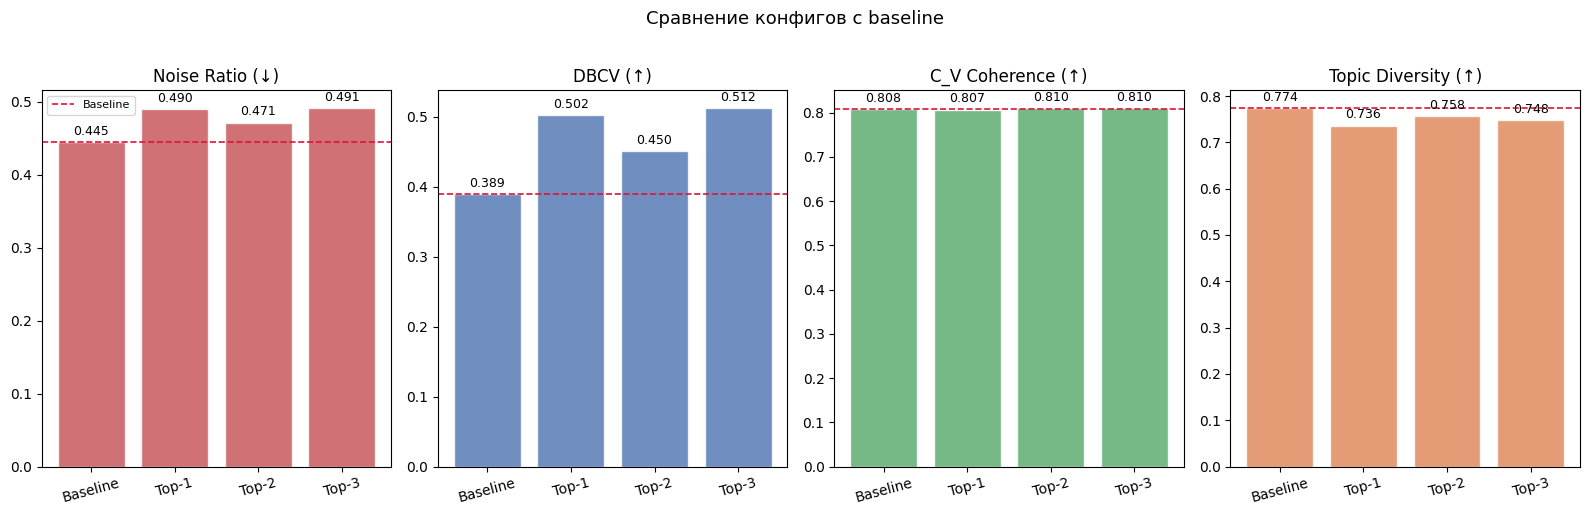

In [20]:
# Визуализация сравнения
metrics_to_plot = ["noise_ratio", "dbcv", "coherence_cv", "topic_diversity"]
titles = ["Noise Ratio (↓)", "DBCV (↑)", "C_V Coherence (↑)", "Topic Diversity (↑)"]
colors = ["#C44E52", "#4C72B0", "#55A868", "#DD8452"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
labels = comparison_df.index.tolist()
x = range(len(labels))

for ax, metric, title, color in zip(axes, metrics_to_plot, titles, colors):
    values = comparison_df[metric].values
    bars = ax.bar(x, values, color=color, alpha=0.8, edgecolor="white")
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
    # Пунктир baseline
    ax.axhline(
        values[0], color="crimson", linestyle="--", linewidth=1.2, label="Baseline"
    )
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15)
    if metric == "noise_ratio":
        ax.legend(fontsize=8)

plt.suptitle("Сравнение конфигов с baseline", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "03_final_comparison.png", bbox_inches="tight", dpi=130)
plt.show()

## 8. Выбор финального конфига и сохранение

Выбираем конфиг с лучшим балансом:  
- DBCV выше baseline  
- Noise Ratio ниже baseline  
- C_V Coherence не упала ниже 0.75 (допустимый порог)  

Эти параметры передаём в `06_topic_evolution.ipynb`.

In [21]:
# Простой скоринг: нормализуем метрики и выбираем лучший
candidates = comparison_df[comparison_df.index != "Baseline"].copy()

# Штрафуем конфиги где coherence_cv < 0.75 - недопустимо
candidates = candidates[candidates["coherence_cv"] >= 0.75]

if len(candidates) == 0:
    print("[!] Ни один конфиг не прошёл порог coherence_cv >= 0.75")
    print("Используем baseline параметры. Попробуй расширить диапазон N_TRIALS.")
    best_label = "Baseline"
else:
    # Комплексный score: DBCV - 0.5 * noise, нормализованные
    candidates["final_score"] = candidates["dbcv"] - 0.5 * candidates["noise_ratio"]
    best_label = candidates["final_score"].idxmax()
    print(f"Лучший конфиг: {best_label}")

best_config = comparison_df.loc[best_label]
best_params = {
    "n_neighbors": int(best_config["n_neighbors"]),
    "n_components": int(best_config["n_components"]),
    "min_cluster_size": int(best_config["min_cluster_size"]),
    "min_samples": int(best_config["min_samples"]),
}

config_path = Path("data/best_hparams.json")
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2, ensure_ascii=False)

print("\nФинальные параметры:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nСохранено: {config_path}")
print("\nСледующий шаг: 06_topic_evolution.ipynb")

Лучший конфиг: Top-3

Финальные параметры:
  n_neighbors: 51
  n_components: 15
  min_cluster_size: 120
  min_samples: 142

Сохранено: data\best_hparams.json

Следующий шаг: 06_topic_evolution.ipynb


## Итоги

### Что сделано
1. **Optuna TPE** - байесовский поиск вместо GridSearch. 30 trials вместо ~80+ для сопоставимого покрытия.
2. **Быстрая оптимизация** - UMAP+HDBSCAN на 50k (без c-TF-IDF). Полный BERTopic только для топ-3.
3. **Целевая функция** - `DBCV - 0.5 * noise_ratio` - явный trade-off между качеством кластеров и их покрытием.

### Источники
- Optuna TPE: https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html
- UMAP параметры: https://umap-learn.readthedocs.io/en/latest/parameters.html
- HDBSCAN параметры: https://hdbscan.readthedocs.io/en/latest/parameter_selection.html
- DBCV metric: https://hdbscan.readthedocs.io/en/latest/api.html#hdbscan.validity.validity_index
- BERTopic parameter tuning: https://maartengr.github.io/BERTopic/getting_started/parameter%20tuning/parametertuning.html
- BERTopic FAQ (large corpora): https://maartengr.github.io/BERTopic/faq.html
- Академическая практика Random Search + DBCV: https://link.springer.com/article/10.1186/s40537-025-01189-4

In [25]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

if ID_COLUMN and ID_COLUMN in df.columns:
    index_map = df[ID_COLUMN].to_numpy()
    index_source = ID_COLUMN
else:
    index_map = df.index.to_numpy()
    index_source = "df.index"

np.save(DATA_DIR / "topics_index_map.npy", index_map)
with open(DATA_DIR / "topics_index_map_meta.json", "w", encoding="utf-8") as f:
    json.dump({"source": index_source, "length": int(len(index_map))}, f, indent=2)

if "topics_by_rank" in globals():
    for rank, topics_list in sorted(topics_by_rank.items()):
        np.save(DATA_DIR / f"topics_top{rank}.npy", np.array(topics_list))
        np.save(DATA_DIR / f"topics_top{rank}_idx.npy", index_map)

    if 1 in topics_by_rank:
        np.save(DATA_DIR / "topics_best_config.npy", np.array(topics_by_rank[1]))
        np.save(DATA_DIR / "topics_best_config_idx.npy", index_map)
else:
    np.save(DATA_DIR / "topics_best_config.npy", np.array(topics))
    np.save(DATA_DIR / "topics_best_config_idx.npy", index_map)

print("Saved topics and index mapping.")
print(f"Index mapping source: {index_source}")

Saved topics and index mapping.
Index mapping source: df.index
